***"Metodologías Avanzadas en Aprendizaje Automático para la Gestión en Organizaciones"***

Trabájo Práctico N° 1 - "Redes Neuronales"

Lea Lambrecht

# MODELOS DE CLASIFICACIÓN

## Librerias

In [ ]:
# https://imbalanced-learn.org
! pip install -U -q imbalanced-learn

In [ ]:
import pandas as pd
import sklearn as sk
from sklearn import model_selection
from sklearn import metrics
from sklearn import tree

from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as sk

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import keras


import numpy as np


## Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Metodologías avanzadas de aprendizaje automático/Unit 3 - Redes Generativas/creditcard.csv')
df = df.sample(frac=1).reset_index(drop=True) # mezcla los datos
df = (df - df.min()) / (df.max() - df.min()) # Normalizamos a [0,1]
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.433608,0.951713,0.778997,0.859426,0.252336,0.767339,0.258074,0.269535,0.785769,0.446426,...,0.557797,0.485080,0.665700,0.387038,0.565812,0.441750,0.421384,0.315075,0.000293,0.0
1,0.806102,0.991313,0.768319,0.790797,0.298085,0.774308,0.256586,0.271682,0.781240,0.445845,...,0.567366,0.556146,0.660623,0.426143,0.627835,0.388079,0.415028,0.311644,0.003270,0.0
2,0.833158,0.994431,0.766599,0.810787,0.257468,0.769090,0.259402,0.266106,0.783224,0.481766,...,0.555956,0.469077,0.669619,0.387070,0.568211,0.459366,0.415121,0.311902,0.000039,0.0
3,0.986249,0.958729,0.776193,0.840163,0.216034,0.770700,0.258288,0.271016,0.784919,0.450050,...,0.557885,0.488613,0.665511,0.320728,0.552014,0.449737,0.421131,0.314824,0.000104,0.0
4,0.824020,0.950141,0.773493,0.835266,0.200814,0.777024,0.276999,0.270536,0.789026,0.469330,...,0.559065,0.511475,0.667396,0.280853,0.520616,0.458965,0.423457,0.315099,0.000754,0.0


In [ ]:
df.shape

(284807, 31)

In [ ]:
df['Class'].value_counts()

,count
Class,
0.0,284315
1.0,492


In [ ]:
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')


No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


El conjunto de datos esta desequilibrado con un 99.83% de casos no fraudulentos y un 0.17% de casos fraudulentos. Si utilizamos este dataframe como base para los modelos predictivos y análisis, se pueden obtener muchos errores y los algoritmos probablemente se sobreajustarán, ya que "asumirán" que la mayoría de las transacciones no son fraude.


<ipython-input-7-b7415a7b365d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=colors)


Text(0.5, 1.0, 'Class Distributions \n (0: No Fraud || 1: Fraud)')

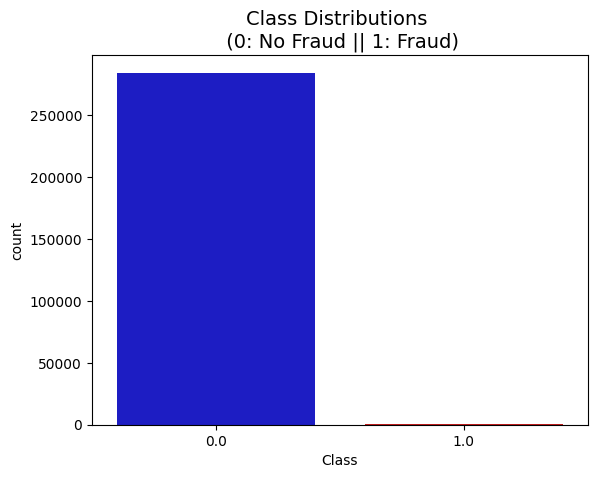

In [ ]:
colors = ["#0101DF", "#DF0101"]
sns.countplot(x='Class', data=df, palette=colors)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

In [ ]:
# Recorte del df
df_no_fraud = df[df['Class'] == 0]
df_fraud = df[df['Class'] == 1]
num_fraud = len(df_fraud) # Número de casos de fraude que deseas mantener
total_size = int(num_fraud / 0.2)  # El 30% de los datos serán fraude
num_no_fraud = total_size - num_fraud  # El resto serán casos sin fraude
num_no_fraud = min(num_no_fraud, len(df_no_fraud))
df_no_fraud_sample = df_no_fraud.sample(n=num_no_fraud, random_state=42)
df1= pd.concat([df_fraud, df_no_fraud_sample]).reset_index(drop=True)
print(df1['Class'].value_counts(normalize=True))


Class
0.0    0.8
1.0    0.2
Name: proportion, dtype: float64


In [ ]:
df1['Class'].value_counts()

,count
Class,
0.0,1968
1.0,492


<ipython-input-10-c8986f0fa111>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df1, palette=colors)


Text(0.5, 1.0, 'Class Distributions \n (0: No Fraud || 1: Fraud)')

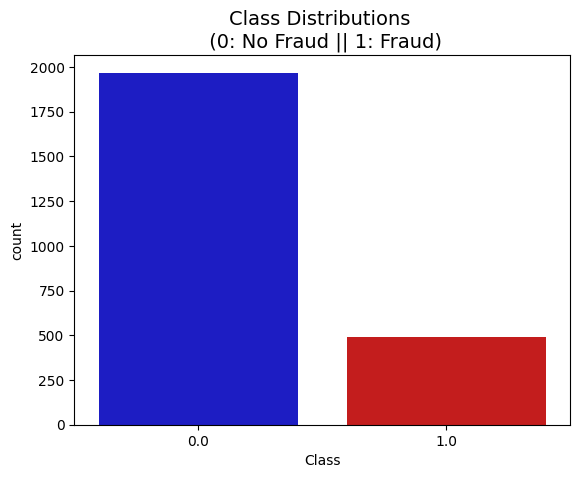

In [ ]:
colors = ["#0101DF", "#DF0101"]
sns.countplot(x='Class', data=df1, palette=colors)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

## MODELO 1 "Decision Tree"

In [ ]:
# Definir los datos
X = df1[df1.columns.drop("Class")] # Variables independientes
y = df1["Class"] # Variable dependiente

In [ ]:
# Definir la función para calcular métricas
def f1_precision_recall(X, y): #Le doy el x e y
# Dividir los datos en entrenamiento y prueba (50% cada uno, con estratificación)
    X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.5, shuffle=True, stratify=y, random_state=42)

# Crear y entrenar el modelo de árbol de decisión
    clf = sk.tree.DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train) #lo entrena
    y_pred = clf.predict(X_test) #predice

# Imprimir las métricas
    print("f1:", sk.metrics.f1_score(y_test, y_pred))
    print("precision:", sk.metrics.precision_score(y_test, y_pred))
    print("recall:", sk.metrics.recall_score(y_test, y_pred))


f1_precision_recall(X, y)

f1: 0.8648648648648649
precision: 0.8851063829787233
recall: 0.8455284552845529


## MODELO 2 "Random Forest"


In [ ]:
# Definir la función para calcular métricas
def f1_precision_recall(X, y):
    # Dividir los datos en entrenamiento y prueba (50% cada uno, con estratificación)
    X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(
        X, y, test_size=0.5, shuffle=True, stratify=y, random_state=42
    )

    # Crear y entrenar el modelo Random Forest
    clf = sk.ensemble.RandomForestClassifier(random_state=42)
    clf.fit(X_train, y_train)  # Entrenar el modelo
    y_pred = clf.predict(X_test)  # Predecir en el conjunto de prueba

    # Imprimir las métricas
    print("f1:", sk.metrics.f1_score(y_test, y_pred))
    print("precision:", sk.metrics.precision_score(y_test, y_pred))
    print("recall:", sk.metrics.recall_score(y_test, y_pred))

f1_precision_recall(X, y)


f1: 0.908695652173913
precision: 0.9766355140186916
recall: 0.8495934959349594


## MODELO 3 "Gradient Boosting"

In [ ]:
# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=42)

# Crear el modelo Gradient Boosting
gbt = GradientBoostingClassifier(random_state=42)

# Entrenar el modelo
gbt.fit(X_train, y_train)

# Predecir en los datos de prueba
y_pred = gbt.predict(X_test)

# Evaluar el modelo
print("F1:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))


F1: 0.9017094017094017
Precision: 0.9504504504504504
Recall: 0.8577235772357723


## Modelo 4 "Keras"


In [ ]:
df1.shape

(2460, 31)

In [ ]:
df1 = df1.astype("float32")

X = df1[df.columns.drop("Class")]
y = df1["Class"]

### Modelo de keras (versión secuencial)

In [ ]:
model = keras.Sequential(
    [
        # entrada
         keras.layers.Input(shape=(X.shape[1],)),

        # capas ocultas
        keras.layers.Dense(256, activation="linear"),
        keras.layers.Dense(128, activation="linear"),
        #keras.layers.Dense(64, activation="linear"),

        # salida
        keras.layers.Dense(1, activation="sigmoid"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │           7,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,961 (160.00 KB)

 Trainable params: 40,961 (160.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# diferentes métricas para evaluar el modelo

metrics = [
    keras.metrics.Precision(name="precision"),
    keras.metrics.Recall(name="recall"),
    keras.metrics.FalseNegatives(name="fn"),
    keras.metrics.FalsePositives(name="fp"),
    keras.metrics.TrueNegatives(name="tn"),
    keras.metrics.TruePositives(name="tp"),
]

# compilamos el modelo
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=metrics)

In [ ]:
history = model.fit(X, y, batch_size=32, epochs=30, validation_split=0.2)

Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - fn: 36.7937 - fp: 8.6984 - loss: 0.1683 - precision: 0.9624 - recall: 0.8472 - tn: 762.7778 - tp: 214.7143 - val_fn: 0.0000e+00 - val_fp: 10.0000 - val_loss: 0.0980 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 482.0000 - val_tp: 0.0000e+00
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - fn: 36.1905 - fp: 8.1111 - loss: 0.1324 - precision: 0.9685 - recall: 0.8608 - tn: 752.8412 - tp: 225.8413 - val_fn: 0.0000e+00 - val_fp: 7.0000 - val_loss: 0.0769 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 485.0000 - val_tp: 0.0000e+00
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - fn: 34.1905 - fp: 7.3333 - loss: 0.1277 - precision: 0.9624 - recall: 0.8672 - tn: 767.4762 - tp: 213.9841 - val_fn: 0.0000e+00 - val_fp: 7.0000 - val_loss: 0.0766 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 485.0000 - val_tp: 0.0000e+00
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - fn: 36.9365 - fp: 

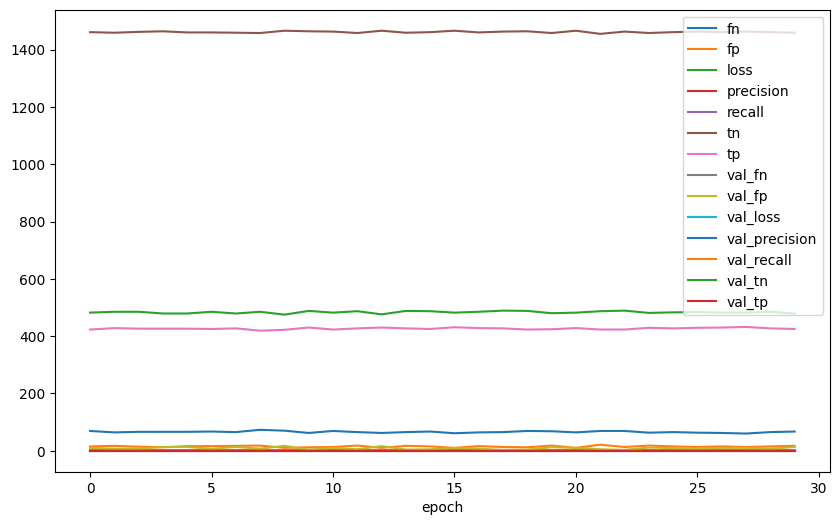

In [ ]:
history = pd.DataFrame(history.history)
history.plot(xlabel="epoch", figsize=(10,6));

In [ ]:
model.predict(X)

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[1.        ],
       [0.93265945],
       [0.9712145 ],
       ...,
       [0.0267013 ],
       [0.06026067],
       [0.0124828 ]], dtype=float32)

### Modelo de keras (versión funcional)

In [ ]:
print(f"Dimensiones de X: {X.shape}")

Dimensiones de X: (2460, 30)


In [ ]:
# entrada
inputs = keras.layers.Input(shape=(30,))
print(inputs.shape)

# capas ocultas
h1 = keras.layers.Dense(256, activation="linear")(inputs)
h2 = keras.layers.Dense(128, activation="linear")(h1)
h3 = keras.layers.Dense(64, activation="linear")(h2)

# salida
outputs = keras.layers.Dense(1, activation="sigmoid")(h2)

model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

(None, 30)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 30)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 256)                 │           7,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,961 (160.00 KB)

 Trainable params: 40,961 (160.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# diferentes métricas para evaluar el modelo

metrics = [
    keras.metrics.Precision(name="precision"),
    keras.metrics.Recall(name="recall"),
    keras.metrics.FalseNegatives(name="fn"),
    keras.metrics.FalsePositives(name="fp"),
    keras.metrics.TrueNegatives(name="tn"),
    keras.metrics.TruePositives(name="tp"),
]

# compilamos el modelo
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=metrics)

In [ ]:
history = model.fit(X, y, batch_size=32, epochs=30, validation_split=0.2)

Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - fn: 191.8889 - fp: 26.2857 - loss: 0.5241 - precision: 0.5526 - recall: 0.2140 - tn: 740.0317 - tp: 64.7778 - val_fn: 0.0000e+00 - val_fp: 1.0000 - val_loss: 0.0616 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 491.0000 - val_tp: 0.0000e+00
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - fn: 61.1270 - fp: 0.7460 - loss: 0.2073 - precision: 0.9964 - recall: 0.7484 - tn: 769.0317 - tp: 192.0794 - val_fn: 0.0000e+00 - val_fp: 1.0000 - val_loss: 0.0518 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 491.0000 - val_tp: 0.0000e+00
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - fn: 51.1905 - fp: 0.8889 - loss: 0.1828 - precision: 0.9959 - recall: 0.7891 - tn: 766.4603 - tp: 204.4444 - val_fn: 0.0000e+00 - val_fp: 3.0000 - val_loss: 0.0968 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_tn: 489.0000 - val_tp: 0.0000e+00
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - fn: 45.5238 - fp: 4

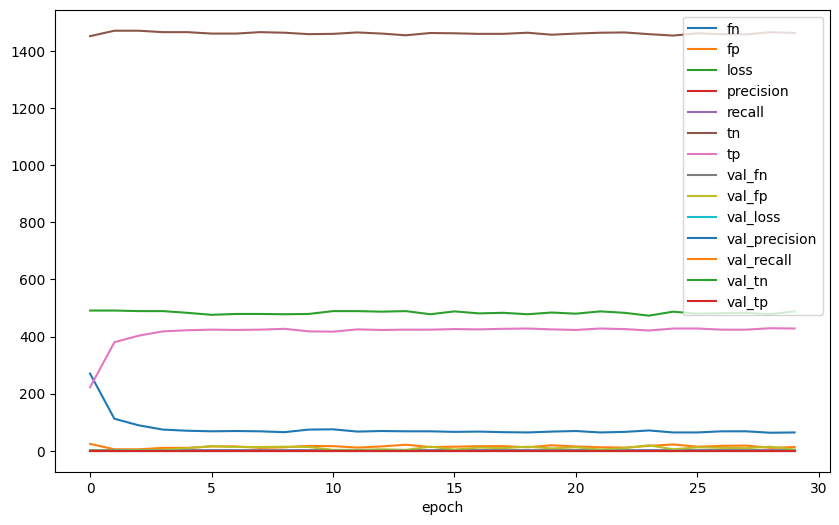

In [ ]:
history = pd.DataFrame(history.history)
history.plot(xlabel="epoch", figsize=(10,6));

In [ ]:
model.predict(X)

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.99999994],
       [0.5803178 ],
       [0.8010519 ],
       ...,
       [0.00278516],
       [0.00585921],
       [0.00118108]], dtype=float32)

# MODELOS DE REGRESIÓN

## LIBRERIAS

In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
!pip install catboost


In [ ]:
import pandas as pd
import numpy as np
import sklearn as sk
import multiprocessing
import tensorflow as tf

from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn import set_config
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import ExtraTreesRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from tensorflow import keras

/content/drive/MyDrive/Metodologías avanzadas de aprendizaje automático/Unit 1 - Aprendizaje Profundo /boston_housing_esp.csv

## Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Metodologías avanzadas de aprendizaje automático/Unit 1 - Aprendizaje Profundo /boston_housing_esp.csv')
df.head()

,precio,metros_totales,antiguedad,precio_terreno,metros_habitables,universitarios,dormitorios,chimenea,banyos,habitaciones,calefaccion,consumo_calefacion,desague,vistas_lago,nueva_construccion,aire_acondicionado
0,132500,0.09,42,50000,906,35,2,1,1.0,5,electric,electric,septic,No,No,No
1,181115,0.92,0,22300,1953,51,3,0,2.5,6,hot water/steam,gas,septic,No,No,No
2,109000,0.19,133,7300,1944,51,4,1,1.0,8,hot water/steam,gas,public/commercial,No,No,No
3,155000,0.41,13,18700,1944,51,3,1,1.5,5,hot air,gas,septic,No,No,No
4,86060,0.11,0,15000,840,51,2,0,1.0,3,hot air,gas,public/commercial,No,Yes,Yes


## Análisis Exploratorio

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   precio              1728 non-null   int64  
 1   metros_totales      1728 non-null   float64
 2   antiguedad          1728 non-null   int64  
 3   precio_terreno      1728 non-null   int64  
 4   metros_habitables   1728 non-null   int64  
 5   universitarios      1728 non-null   int64  
 6   dormitorios         1728 non-null   int64  
 7   chimenea            1728 non-null   int64  
 8   banyos              1728 non-null   float64
 9   habitaciones        1728 non-null   int64  
 10  calefaccion         1728 non-null   object 
 11  consumo_calefacion  1728 non-null   object 
 12  desague             1728 non-null   object 
 13  vistas_lago         1728 non-null   object 
 14  nueva_construccion  1728 non-null   object 
 15  aire_acondicionado  1728 non-null   object 
dtypes: flo

In [ ]:
df.isna().sum().sort_values()

,0
precio,0
metros_totales,0
antiguedad,0
precio_terreno,0
metros_habitables,0
universitarios,0
dormitorios,0
chimenea,0
banyos,0
habitaciones,0


In [ ]:
# Se unifican los valores de la variable chimenea
dic_replace = {'2': "2_mas",
               '3': "2_mas",
               '4': "2_mas"}

df['chimenea'] = df['chimenea'] \
                     .map(dic_replace) \
                     .fillna(df['chimenea'])
df.chimenea.value_counts().sort_index()

<ipython-input-31-d932c1759713>:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(df['chimenea'])


,count
chimenea,
0,740
1,942
2,42
3,2
4,2


## Preprocesamiento

In [ ]:
# Identificación de columnas num y cat
numeric_cols = df.select_dtypes(include=['float64', 'int']).columns.to_list()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.to_list()

In [ ]:
# Transformación de las variables num y cat
num = Pipeline(steps=[('scaler', StandardScaler())])
cat = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [ ]:
# Combinación de pipelines en un ColumnTransformer
preprocessor = ColumnTransformer(transformers=[('num', num, numeric_cols),('cat', cat, cat_cols)])


In [ ]:
preprocesador = ColumnTransformer(transformers=[('numeric', num, numeric_cols), ('cat', cat, cat_cols)],remainder='passthrough')
set_config(display='diagram')

In [ ]:
# Ajustar y transformar el DataFrame completo
df_prep = preprocessor.fit_transform(df)

In [ ]:
# Obtener nombres de las columnas transformadas
encoded_cat = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols)
labels = numeric_cols + list(encoded_cat)

# Convertir a DataFrame con nombres de columnas
df_prep = pd.DataFrame(df_prep, columns=labels)
df_prep.head()

,precio,metros_totales,antiguedad,precio_terreno,metros_habitables,universitarios,dormitorios,chimenea,banyos,habitaciones,...,consumo_calefacion_oil,desague_none,desague_public/commercial,desague_septic,vistas_lago_No,vistas_lago_Yes,nueva_construccion_No,nueva_construccion_Yes,aire_acondicionado_No,aire_acondicionado_Yes
0,-0.807483,-0.587297,0.482300,0.441084,-1.369854,-1.990952,-1.412915,0.716169,-1.367709,-0.881632,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
1,-0.313492,0.601001,-0.955980,-0.350095,0.319520,-0.442154,-0.189097,-1.082582,0.911366,-0.449812,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
2,-1.046272,-0.444129,3.598575,-0.778531,0.304998,-0.442154,1.034721,0.716169,-1.367709,0.413827,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,-0.578854,-0.129158,-0.510798,-0.452920,0.304998,-0.442154,-0.189097,0.716169,-0.608017,-0.881632,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
4,-1.279372,-0.558664,-0.955980,-0.558601,-1.476348,-0.442154,-1.412915,-1.082582,-1.367709,-1.745271,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


## Train y Test

In [ ]:
from sklearn.model_selection import train_test_split

# Suponiendo que 'df_prep' contiene tus datos y 'precio' es tu target
X = df_prep.drop('precio', axis=1)  # Características (features)
y = df_prep['precio']                # Variable objetivo (target)

# Separar en entrenamiento y prueba (80% train - 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

# Ahora X_train y X_test contienen tus datos separados en entrenamiento y prueba


In [ ]:
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (1382, 24)
Dimensiones de X_test: (346, 24)
Dimensiones de y_train: (1382,)
Dimensiones de y_test: (346,)


## Modelos de Ensambles

In [ ]:
models = {
    'linear': LinearRegression(),
    'ridge': Ridge(random_state=42),
    'ex-trees':ExtraTreesRegressor(random_state = 42),
    'lgbm':LGBMRegressor(random_state = 42),
    'xgboost':XGBRegressor(random_state = 42),
    'rand-forst' : RandomForestRegressor(random_state = 42)
 }

In [ ]:
def train_model(models: dict) -> pd.DataFrame:

    metricas = {}
    name_list, train_score_list, r_sqd_list, mae_list, rmse_list = [], [], [], [], []
    for name, estimator in models.items():

        # fit
        estimator.fit(X_train, y_train)

        # predictor
        y_pred = estimator.predict(X_test)

        # metricas
        train_score = estimator.score(X_train, y_train)
        r_sqd = metrics.r2_score(y_test, y_pred)
        mae = metrics.mean_absolute_error(y_test, y_pred)
        mse = metrics.mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)

        # nombre de metricas en las listas
        name_list.append(name)
        train_score_list.append(train_score)
        r_sqd_list.append(r_sqd)
        mae_list.append(mae)
        rmse_list.append(rmse)

    metricas["Name"] = name_list
    metricas["Train_Score"] = train_score_list
    metricas["R_squared"] = r_sqd_list
    metricas["Mean_absolute_error"] = mae_list
    metricas["Root_mean_sqd_error"] = rmse_list

    resume = pd.DataFrame(metricas)
    reseume = resume.sort_values("Root_mean_sqd_error")
    return resume

In [ ]:
train_model(models)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000826 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 805
[LightGBM] [Info] Number of data points in the train set: 1382, number of used features: 21
[LightGBM] [Info] Start training from score -0.005387


,Name,Train_Score,R_squared,Mean_absolute_error,Root_mean_sqd_error
0,linear,0.664189,0.612102,0.449290,0.661576
1,ridge,0.664167,0.611891,0.449472,0.661756
2,ex-trees,1.000000,0.635745,0.420606,0.641097
3,lgbm,0.920920,0.645018,0.406248,0.632884
4,xgboost,0.994935,0.603974,0.424344,0.668472
5,rand-forst,0.956201,0.636977,0.419020,0.640012


## Modelo Keras

In [ ]:
# Entrada
inputs = keras.layers.Input(shape=(24,))

# Capas ocultas
h1 = keras.layers.Dense(256, activation="relu")(inputs)
h2 = keras.layers.Dense(128, activation="relu")(h1)

# Salida para regresión
outputs = keras.layers.Dense(1, activation="linear")(h2)

# Definir el modelo
model = keras.Model(inputs=inputs, outputs=outputs)

# Mostrar la estructura del modelo
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │           6,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,425 (154.00 KB)

 Trainable params: 39,425 (154.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(X.shape)

(1728, 24)


In [ ]:
# diferentes métricas para evaluar el modelo

metrics = [
    keras.metrics.Precision(name="precision"),
    keras.metrics.Recall(name="recall"),
    keras.metrics.FalseNegatives(name="fn"),
    keras.metrics.FalsePositives(name="fp"),
    keras.metrics.TrueNegatives(name="tn"),
    keras.metrics.TruePositives(name="tp"),
]

# compilamos el modelo
model.compile(optimizer="adam", loss="mse", metrics=["mae", "mse", "RootMeanSquaredError"])

In [ ]:
history = model.fit(X, y, batch_size=32, epochs=30, validation_split=0.2)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - RootMeanSquaredError: 1.0149 - loss: 1.0876 - mae: 0.7204 - mse: 1.0876 - val_RootMeanSquaredError: 0.5040 - val_loss: 0.2540 - val_mae: 0.3909 - val_mse: 0.2540
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - RootMeanSquaredError: 0.6026 - loss: 0.3648 - mae: 0.4111 - mse: 0.3648 - val_RootMeanSquaredError: 0.6337 - val_loss: 0.4016 - val_mae: 0.5355 - val_mse: 0.4016
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - RootMeanSquaredError: 0.5427 - loss: 0.2955 - mae: 0.3735 - mse: 0.2955 - val_RootMeanSquaredError: 0.5635 - val_loss: 0.3176 - val_mae: 0.4608 - val_mse: 0.3176
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - RootMeanSquaredError: 0.5349 - loss: 0.2868 - mae: 0.3672 - mse: 0.2868 - val_RootMeanSquaredError: 0.5611 - val_loss: 0.3148 - val_mae: 0.4521 - val_mse: 0.3148
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - RootMeanSquaredError: 0.5591 - loss: 0.3142 - mae: 0.3784 - mse: 0.3142 - val_RootMeanSquar

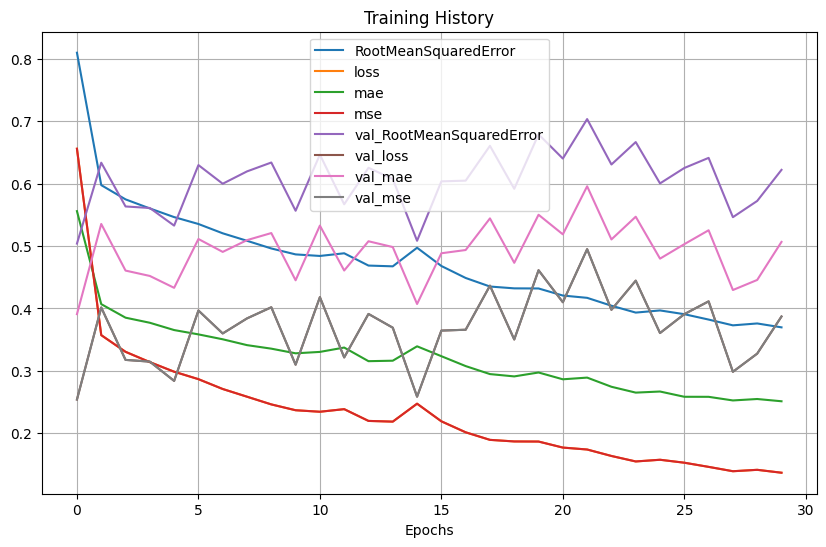

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# Convertir el historial del entrenamiento en un DataFrame de Pandas
history_df = pd.DataFrame(history.history)

# Visualizar métricas relevantes (por ejemplo, pérdida y validación)
history_df.plot(figsize=(10, 6))
plt.xlabel("Epochs")
plt.title("Training History")
plt.grid(True)
plt.show()